R = 2.986 fm, a = 0.67 fm
V0 (Bohr-Mottelson) = 48.46 MeV,  V0 (tuned to S_n) = 42.68 MeV,  V_ls = 18.78 MeV

Bound neutron levels in 13C (MeV):
  0s1/2   E =  -21.740
  0p3/2   E =   -9.366
  0p1/2   E =   -4.946


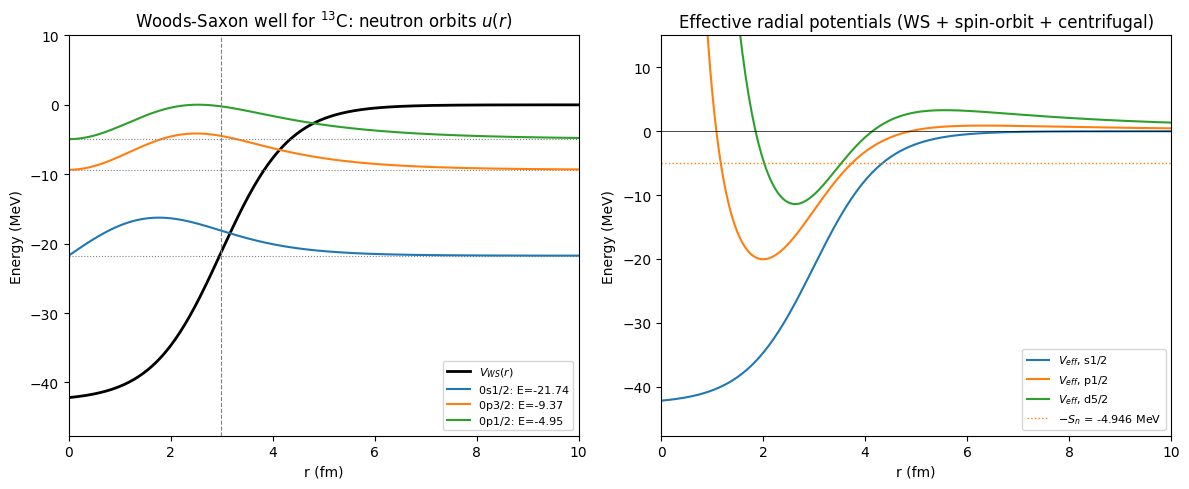

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt

"""
Woods-Saxon well tuned to 13C
-----------------------------
Model 13C as a 12C core + one valence neutron in a Woods-Saxon potential.
This the *radial* problem in 3D, in physical units:

    -hbar^2/(2 mu) u''(r) + [ V_WS(r) + V_so(r) <l.s> + hbar^2 l(l+1)/(2 mu r^2) ] u(r) = E u(r)

with u(0) = 0 and psi(r) = u(r)/r * Y_lm.

    V_WS(r) = -V0 f(r),          f(r) = 1 / (1 + exp((r - R)/a))
    V_so(r) =  V_ls r0^2 (1/r) df/dr        (negative at the surface)

Width:  R = r0 A^(1/3) with r0 = 1.27 fm, diffuseness a = 0.67 fm (Bohr-Mottelson).
Depth:  start from the Bohr-Mottelson neutron value V0 = 51 - 33 (N-Z)/A MeV,
        V_ls = 0.44 V0, then fine-tune V0 so the 0p1/2 orbit (the valence neutron
        in 13C, J^pi = 1/2-) is bound by the measured S_n(13C) = 4.946 MeV.

Units: MeV, fm.
"""
import numpy as np
import matplotlib.pyplot as plt
import qutip as qt
from scipy.optimize import brentq

# ---- 1. Nucleus and constants ---------------------------------------------
Z, N_n = 6, 7
A = Z + N_n
hbarc = 197.327                      # MeV fm
m_n, m_core = 939.565, 11177.93      # neutron and 12C masses (MeV)
mu = m_n * m_core / (m_n + m_core)   # reduced mass
h2m = hbarc**2 / (2 * mu)            # hbar^2/(2 mu)  ~ 22.5 MeV fm^2
S_n = 4.946                          # neutron separation energy of 13C (MeV)

r0, a = 1.27, 0.67                   # fm
R = r0 * A**(1/3)                    # ~ 2.98 fm
V0_BM = 51.0 - 33.0 * (N_n - Z) / A  # Bohr-Mottelson depth for neutrons
ls_ratio = 0.44                      # V_ls / V0

# ---- 2. Radial grid (u(0) = 0 and u(r_max) = 0 are built in) ---------------
N_r, r_max = 800, 25.0
r = np.linspace(r_max / N_r, r_max, N_r)
dr = r[1] - r[0]

f = 1.0 / (1.0 + np.exp((r - R) / a))
dfdr = -f * (1.0 - f) / a

kin = h2m * (np.diag(np.full(N_r, 2.0))
             - np.diag(np.ones(N_r - 1), 1)
             - np.diag(np.ones(N_r - 1), -1)) / dr**2

def ls(l, j):
    return 0.5 * (j * (j + 1) - l * (l + 1) - 0.75)

def V_eff(V0, l, j):
    """Woods-Saxon + spin-orbit + centrifugal, for a given (l, j)."""
    V_ws = -V0 * f
    V_so = ls_ratio * V0 * r0**2 * dfdr / r * ls(l, j)
    return V_ws + V_so + h2m * l * (l + 1) / r**2

def H_lj(V0, l, j):
    return qt.Qobj(kin + np.diag(V_eff(V0, l, j)))

def bound_states(V0, l, j, n_max=4):
    E, kets = H_lj(V0, l, j).eigenstates(eigvals=n_max)
    keep = E < 0                                      # bound states only
    return E[keep], [k for k, b in zip(kets, keep) if b]

# ---- 3. Tune the depth to 13C ---------------------------------------------
def E_0p12(V0):
    return bound_states(V0, 1, 0.5)[0][0]

V0 = brentq(lambda v: E_0p12(v) + S_n, 30.0, 80.0)
print(f"R = {R:.3f} fm, a = {a} fm")
print(f"V0 (Bohr-Mottelson) = {V0_BM:.2f} MeV,  V0 (tuned to S_n) = {V0:.2f} MeV,"
      f"  V_ls = {ls_ratio * V0:.2f} MeV")

# ---- 4. Single-particle spectrum ------------------------------------------
orbits = [(0, 0.5, "s1/2"), (1, 1.5, "p3/2"), (1, 0.5, "p1/2"),
          (2, 2.5, "d5/2"), (2, 1.5, "d3/2")]
levels = []                                           # (E, label, u(r))
print("\nBound neutron levels in 13C (MeV):")
for l, j, name in orbits:
    E, kets = bound_states(V0, l, j)
    for n, (En, k) in enumerate(zip(E, kets)):
        u = k.full().flatten().real / np.sqrt(dr)     # normalized: int u^2 dr = 1
        u *= np.sign(u[np.argmax(np.abs(u))])
        levels.append((En, f"{n}{name}", u, l, j))
        print(f"  {n}{name:5s}  E = {En:8.3f}")
levels.sort(key=lambda t: t[0])

# ---- 5. Plots -------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(r, -V0 * f, "k", lw=2, label="$V_{WS}(r)$")
scale = 8.0
for E, lab, u, l, j in levels:
    ax1.axhline(E, color="gray", ls=":", lw=0.8)
    ax1.plot(r, E + scale * u, label=f"{lab}: E={E:.2f}")
ax1.axvline(R, color="gray", ls="--", lw=0.8)
ax1.set_xlim(0, 10)
ax1.set_ylim(-V0 - 5, 10)
ax1.set_xlabel("r (fm)")
ax1.set_ylabel("Energy (MeV)")
ax1.set_title(r"Woods-Saxon well for $^{13}$C: neutron orbits $u(r)$")
ax1.legend(fontsize=8, loc="lower right")

# Effective potentials for the valence orbit's partial wave
for l, j, name in [(0, 0.5, "s1/2"), (1, 0.5, "p1/2"), (2, 2.5, "d5/2")]:
    ax2.plot(r, V_eff(V0, l, j), label=f"$V_{{eff}}$, {name}")
ax2.axhline(-S_n, color="C1", ls=":", lw=1, label=f"$-S_n$ = {-S_n} MeV")
ax2.axhline(0, color="k", lw=0.5)
ax2.set_xlim(0, 10)
ax2.set_ylim(-V0 - 5, 15)
ax2.set_xlabel("r (fm)")
ax2.set_ylabel("Energy (MeV)")
ax2.set_title("Effective radial potentials (WS + spin-orbit + centrifugal)")
ax2.legend(fontsize=8, loc="lower right")

plt.tight_layout()
plt.show()